#### Multiple Schemas and state seperation

Boilerplate code

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)


Parallelization

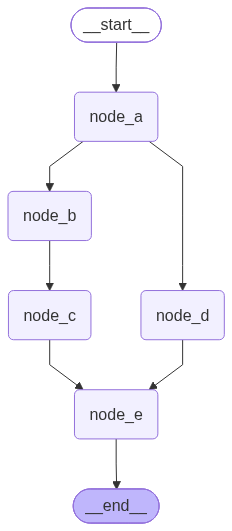

================================ Human Message =================================

Hi I'm vishwa
================================ Human Message =================================

I'm A
================================ Human Message =================================

I'm B
================================ Human Message =================================

I'm D
================================ Human Message =================================

I'm C
================================ Human Message =================================

I'm E
================================ Human Message =================================

I'm E


In [4]:
from langgraph.graph import StateGraph,START,END,MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator
import time

class State(MessagesState):
    pass

builder = StateGraph(State)

def node_a(state : State):
    time.sleep(1)
    return {"messages":"I'm A"}

def node_b(state : State):
    time.sleep(1)
    return {"messages":"I'm B"}

def node_c(state : State):
    time.sleep(1)
    return {"messages":"I'm C"}

def node_d(state : State):
    time.sleep(1)
    return {"messages":"I'm D"}

def node_e(state : State):
    time.sleep(1)
    return {"messages":"I'm E"}

builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_a","node_d")
builder.add_edge("node_b","node_c")
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
builder.add_edge("node_e",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

res = graph.invoke({"messages":"Hi I'm vishwa"})

for r in res.get("messages"):
    r.pretty_print()





streaming the above messages

In [7]:
events = graph.stream({"messages":"I'm vishwa"}, stream_mode="values")

prev_count = 0
for event in events:
    # event.get("messages")[-1].pretty_print() # only prints the last output during parallel execution

    # Offsetting the printed message to overcome this disadvantage
    msgs = event.get("messages")
    for msg in msgs[prev_count:]:
        msg.pretty_print()
    prev_count = len(msgs)



================================ Human Message =================================

I'm vishwa
================================ Human Message =================================

I'm A
================================ Human Message =================================

I'm B
================================ Human Message =================================

I'm D
================================ Human Message =================================

I'm C
================================ Human Message =================================

I'm E
================================ Human Message =================================

I'm E


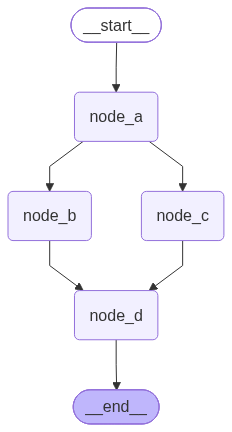

In [8]:
from langgraph.graph import START,END,StateGraph,MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator
import time

class State(MessagesState):
    pass

builder = StateGraph(State)

def node_a(state : State):
    return {"messages":"I'm A"}

def node_b(state : State):
    return {"messages":"I'm B"}

def node_c(state : State):
    return {"messages":"I'm C"}

def node_d(state : State):
    return {"messages":"I'm D"}

builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_a","node_c")
builder.add_edge("node_b","node_d")
builder.add_edge("node_c","node_d")
builder.add_edge("node_d",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))






In [9]:
res = graph.invoke({"messages":"Hi, I'm vishwa"})

for r in res.get("messages"):
    r.pretty_print()

================================ Human Message =================================

Hi, I'm vishwa
================================ Human Message =================================

I'm A
================================ Human Message =================================

I'm B
================================ Human Message =================================

I'm C
================================ Human Message =================================

I'm D


**Custom Reducer to control order of execution**

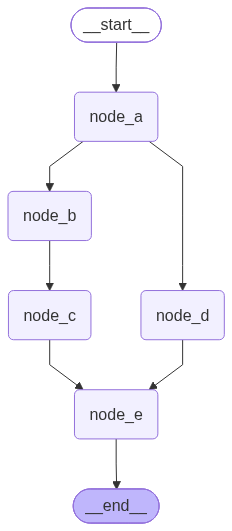

In [11]:
from langgraph.graph import START,END,StateGraph,MessagesState
from typing import TypedDict, Annotated, List
from IPython.display import display, Image
import operator
import time

def custom_reducer(left, right):

    if not isinstance(left, list):
        left = [left]
         
    if not isinstance(right, list):
        right = [right]

    print(f"Left is {left}")
    print(f"Right is {right}\n\n")

    return sorted(left + right, reverse=False) #sorts based on text output, in actual production line, sorting is based on type like this

class State(TypedDict):
    messages : Annotated[list,custom_reducer]

builder = StateGraph(State)

def node_a(state : State):
    return {"messages":"I'm A"}

def node_b(state : State):
    return {"messages":"I'm B"}

def node_c(state : State):
    return {"messages":"I'm C"}

def node_d(state : State):
    return {"messages":"I'm D"}

def node_e(state : State):
    return {"messages":"I'm E"}


builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b","node_c")
builder.add_edge("node_a","node_d")
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
builder.add_edge("node_e",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [13]:
res = graph.invoke({"messages":"I'm vishwa"})

for r in res.get("messages"):
    print(r)


Left is []
Right is ["I'm vishwa"]


Left is ["I'm vishwa"]
Right is ["I'm A"]


Left is ["I'm A", "I'm vishwa"]
Right is ["I'm B"]


Left is ["I'm A", "I'm B", "I'm vishwa"]
Right is ["I'm D"]


Left is ["I'm A", "I'm B", "I'm D", "I'm vishwa"]
Right is ["I'm C"]


Left is ["I'm A", "I'm B", "I'm C", "I'm D", "I'm vishwa"]
Right is ["I'm E"]


Left is ["I'm A", "I'm B", "I'm C", "I'm D", "I'm E", "I'm vishwa"]
Right is ["I'm E"]


I'm A
I'm B
I'm C
I'm D
I'm E
I'm E
I'm vishwa
